# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [ ]:
# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. 
# All work submitted is my own and reflects my understanding of the material.

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [9]:
g = 9.8 #m/s
L = 1 #m

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [11]:
def pendulum(t, y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -(g/L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [13]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [15]:
t_span = (0, 10)
y0 =[1.0, 0.0]
eval = np.linspace(0,10, 100)

sol = solve_ivp(pendulum, t_span, y0, t_eval=eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [17]:
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [23]:
t_theoretical = 2 * np.pi * np.sqrt(L/g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [26]:
print(t_theoretical)

2.007089923154493


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [29]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

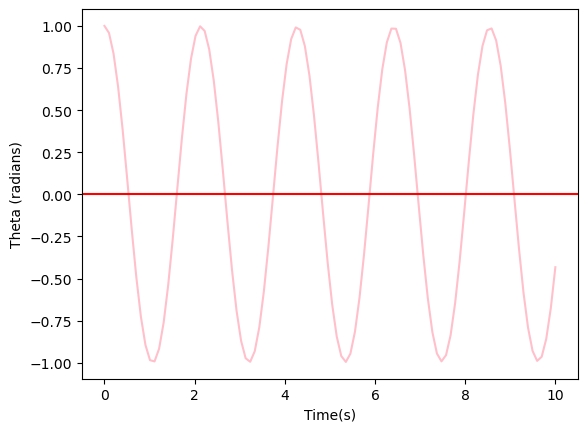

In [31]:
plt.plot(time_values, theta_values, color="pink")
plt.xlabel("Time(s)")
plt.ylabel("Theta (radians)")
plt.axhline(y=0, color="red")

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [36]:
print(f"{T_numerical:.4g}")

2.02


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [39]:
# The numerical approximation is very close to the actual results

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [42]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [46]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [49]:
df = pd.read_csv('owid-covid-data.csv')

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [51]:
country = "United States"
df_country = df[df["location"] == country]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [53]:
df_country = df_country[["date","total_cases"]].dropna()

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [55]:
df_country['days_since_start']= range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [57]:
print(df_country.head())

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4


In [58]:
number_columns = len(df_country)
print(df_country)

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4
...            ...          ...               ...
405120  2024-07-31  103436829.0              1669
405121  2024-08-01  103436829.0              1670
405122  2024-08-02  103436829.0              1671
405123  2024-08-03  103436829.0              1672
405124  2024-08-04  103436829.0              1673

[1674 rows x 3 columns]


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [60]:
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [62]:
import math

def exponential_growth(t, C_0, r):
    Ct = C_0 * (math.e **(r*t))
    return Ct

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [64]:
days = df_country["days_since_start"].values[:30]
cases = df_country["total_cases"].values[:30]

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [66]:
p0 = [1, 0.1]
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])
C_0_fit, r_fit = popt

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [73]:
C0_fit, r_fit = popt
print(C0_fit)
print(r_fit)

0.12389531502191689
0.15384246877506502


Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [174]:
print(f"{C0_fit:.2g}")
print(f"{r_fit:.4g}")

0.12
0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [177]:
future_days = np.arange(0, 60)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [180]:
predicted_cases = exponential_growth(future_days,*popt)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

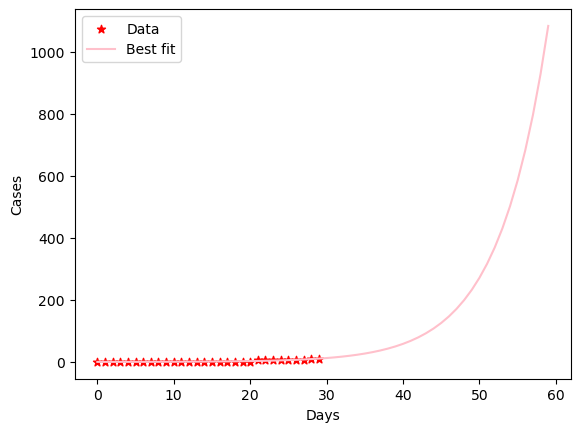

In [183]:
plt.scatter(days, cases, label="Data", marker = '*', color="red")

plt.plot(future_days, predicted_cases, label="Best fit", color="pink")

plt.xlabel("Days")
plt.ylabel("Cases")

plt.legend()

How well does your exponential model fit the actual COVID-19 data? 

In [186]:
# It fits the data incredibly well, follows the pattern almost exactly

Make another plot but this time to **90 days**.

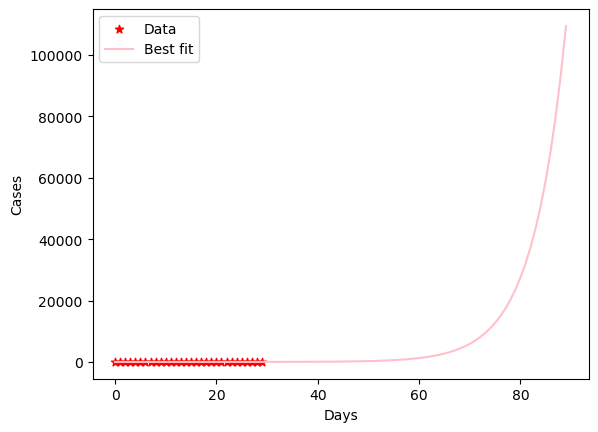

In [189]:
future_days_90 = np.arange(0, 90)
predicted_cases = exponential_growth(future_days_90,*popt)

plt.scatter(days, cases, label="Data", marker = '*', color="red")

plt.plot(future_days_90, predicted_cases, label="Best fit", color="pink")

plt.xlabel("Days")
plt.ylabel("Cases")
plt.legend()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [191]:
predicted_cases = exponential_growth(87,*popt)
print(predicted_cases)

80497.10337124694


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [81]:
%pip install seaborn
import seaborn as sns

sns.load_dataset('penguins')

Note: you may need to restart the kernel to use updated packages.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

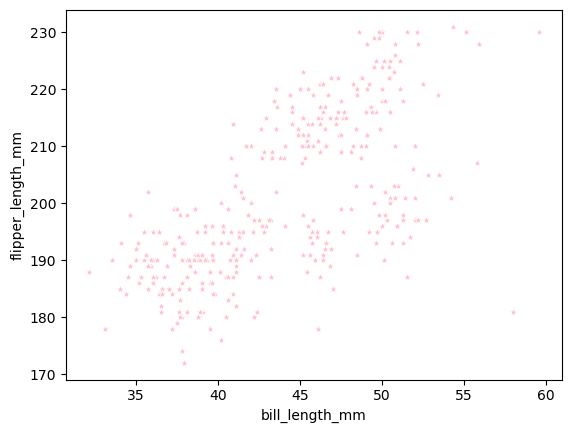

In [89]:
#extracting data
penguins = pd.read_csv('penguins.csv')
penguins = penguins[["bill_length_mm","flipper_length_mm"]].dropna()

#plotting
sns.scatterplot(data=penguins, x='bill_length_mm', y='flipper_length_mm', color='pink', marker = '*')

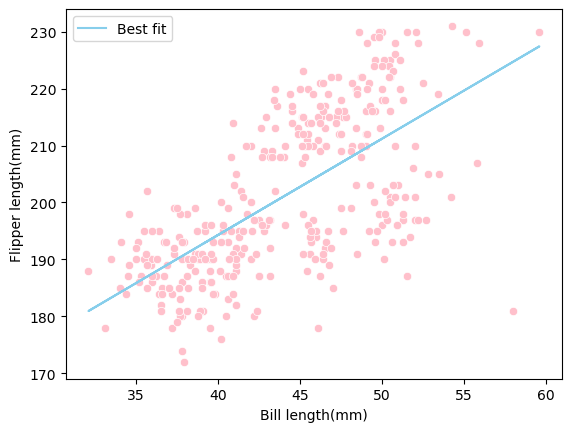

In [87]:
#curve fitting
bill_len = penguins["bill_length_mm"]
flipper_len = penguins["flipper_length_mm"]

def line_of_bestfit(bill_len, a, b):
    flipper = (a * bill_len) + b
    return flipper

p0 = [1, 0.1]
popt, pcov = curve_fit(line_of_bestfit, bill_len, flipper_len, p0=[1, 0.1])
a_fit, b_fit = popt

best_fit = line_of_bestfit(bill_len,*popt)

sns.scatterplot(data=penguins, x='bill_length_mm', y='flipper_length_mm', color='pink')

plt.plot(bill_len, best_fit, label="Best fit", color="skyblue")

plt.xlabel("Bill length(mm)")
plt.ylabel("Flipper length(mm)")
plt.legend()

On it's own branch, submit this notebook to Gradescope! 